In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/catvnoncat/catvnoncat/train_catvnoncat.h5
/kaggle/input/catvnoncat/catvnoncat/test_catvnoncat.h5


In [2]:
import numpy as np
import h5py
train_dataset = h5py.File('/kaggle/input/catvnoncat/catvnoncat/train_catvnoncat.h5', "r")
test_dataset = h5py.File('/kaggle/input/catvnoncat/catvnoncat/test_catvnoncat.h5', "r")

print(train_dataset.keys()) # train dataset is a dictionary with keys and values


<KeysViewHDF5 ['list_classes', 'train_set_x', 'train_set_y']>


In [3]:
# accessing the images

print(type(train_dataset['train_set_x']))
print(type(train_dataset['train_set_x'][:]))
print((train_dataset['train_set_x']).shape)
print((train_dataset['train_set_x'][:]).shape)
print((train_dataset['train_set_x']).dtype)

<class 'h5py._hl.dataset.Dataset'>
<class 'numpy.ndarray'>
(209, 64, 64, 3)
(209, 64, 64, 3)
uint8


In [4]:
def load_dataset():
    # REPLACE the strings below with the file paths you found in Step 2
    train_dataset = h5py.File('/kaggle/input/catvnoncat/catvnoncat/train_catvnoncat.h5', "r")
    test_dataset = h5py.File('/kaggle/input/catvnoncat/catvnoncat/test_catvnoncat.h5', "r")

    train_set_x_orig = np.array(train_dataset["train_set_x"][:]) # your train set features
    train_set_y_orig = np.array(train_dataset["train_set_y"][:]) # your train set labels

    test_set_x_orig = np.array(test_dataset["test_set_x"][:]) # your test set features
    test_set_y_orig = np.array(test_dataset["test_set_y"][:]) # your test set labels

    classes = np.array(test_dataset["list_classes"][:]) # the list of classes
    
    return train_set_x_orig, train_set_y_orig, test_set_x_orig, test_set_y_orig, classes

In [5]:
train_set_x_orig, train_set_y_orig, test_set_x_orig, test_set_y_orig, classes = load_dataset()
print(classes)

[b'non-cat' b'cat']


In [6]:
print(train_set_x_orig.shape)
print(train_set_y_orig.shape)
print(test_set_x_orig.shape)
print(test_set_y_orig.shape)

(209, 64, 64, 3)
(209,)
(50, 64, 64, 3)
(50,)


In [7]:
train_set_y_orig = train_set_y_orig.reshape((train_set_y_orig.shape[0],1))
test_set_y_orig = test_set_y_orig.reshape((test_set_y_orig.shape[0],1))
print(train_set_y_orig.shape)
print(test_set_y_orig.shape)

(209, 1)
(50, 1)


In [8]:
cat_indices = np.where(train_set_y_orig[:,0] ==1)  # returns a tuple of arrays. first array is row indices and second array is column indices
print('Tuple of row and column indices where y ==1',cat_indices)

Tuple of row and column indices where y ==1 (array([  2,   7,  11,  13,  14,  19,  24,  25,  27,  29,  38,  41,  42,
        47,  50,  54,  56,  57,  59,  60,  61,  68,  71,  83,  84,  88,
        92,  93,  94,  97, 102, 104, 106, 107, 108, 109, 110, 111, 117,
       121, 124, 126, 128, 129, 133, 134, 135, 136, 137, 142, 144, 145,
       146, 148, 149, 153, 156, 162, 164, 166, 169, 170, 171, 174, 175,
       177, 179, 185, 188, 192, 197, 200]),)


In [9]:
print('The shape of the flipped dataset is: ', train_set_x_orig[cat_indices[0]].shape)

The shape of the flipped dataset is:  (72, 64, 64, 3)


In [10]:
# horizontal flipping the cat images


X_augmented = [train_set_x_orig] # Start with the original data
Y_augmented = [train_set_y_orig]

def flip(X_orig, Y_orig): # takes in 209, 64, 64, 3 training data and for every cat images (Y_orig ==1), it flips the image. 

    cat_indices = np.where(Y_orig ==1)[0]
    flipped_cats = np.flip(X_orig[cat_indices],axis =2)
    labels = np.ones((flipped_cats.shape[0],1))
    return flipped_cats, labels

X_flipped,Y_flipped =  flip(train_set_x_orig, train_set_y_orig)
X_augmented.append(X_flipped)
Y_augmented.append(Y_flipped)

train_set_x_orig = np.concatenate(X_augmented, axis=0)
train_set_y_orig= np.concatenate(Y_augmented ,axis=0)


print('The shape of enlarged training dataset',train_set_x_orig.shape)
print('The shape of the enlarged labels',train_set_y_orig.shape)

The shape of enlarged training dataset (281, 64, 64, 3)
The shape of the enlarged labels (281, 1)


**Cat vs non-cat distribution is almost 50-50% with 144 cats and 137 non-cats**

In [11]:
angles = np.random.randint(-30,30)

angles

27

In [12]:
X_4d = train_set_x_orig[0,1]
print(X_4d.shape)
X_4d = train_set_x_orig[[0,3]] # fancy indexing # takes the 0th image and 3rd image and then stack them up.
print(X_4d.shape)

X_4d = train_set_x_orig[[0,3],[1,2]]
print(X_4d.shape)

X_4d = train_set_x_orig[[0,3],[1,2],[3,4]]
print(X_4d.shape)

(64, 3)
(2, 64, 64, 3)
(2, 64, 3)
(2, 3)


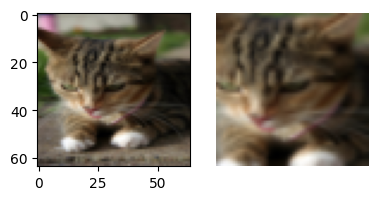

In [13]:
# function for cropping 

import cv2
import matplotlib.pyplot as plt

def apply_center_crop(X_4d, zoom_factor=0.7):
    """
    X_4d: (m, 64, 64, 3)
    zoom_factor: 0.75 means we take the middle 75% (48x48 pixels)
    """
    m, h, w, c = X_4d.shape
    # Calculate crop size (e.g., 48x48)
    crop_h, crop_w = int(h * zoom_factor), int(w * zoom_factor)
    
    # Calculate start points to center the crop
    start_h = (h - crop_h) // 2
    start_w = (w - crop_w) // 2
    
    X_cropped = np.zeros_like(X_4d)

    """Pre-allocation (np.zeros_like): You are creating the empty X_cropped array before the loop starts. 
    This is a "Basic Best Practice." If you tried to append images to a list inside the loop (e.g., list.append()), 
    it would be much slower because Python would have to re-allocate memory for the list every single time it grows."""
    
    for i in range(m):
        # 1. Slicing the middle
        img_crop = X_4d[i, start_h:start_h+crop_h, start_w:start_w+crop_w, :]
        # 2. Resizing back to 64x64
        X_cropped[i] = cv2.resize(img_crop, (w, h), interpolation=cv2.INTER_LINEAR)

        """You used cv2.resize(img_crop, (w, h)). A common mistake is passing (h, w), but OpenCV specifically expects (width, height). 
        Since your X_4d.shape gave you (m, h, w, c), passing (w, h) is exactly right"""
        
    return X_cropped


img_index = np.random.randint(0,train_set_x_orig.shape[0]) # randomly selecting an image and cropping it.
X_4d = train_set_x_orig[[img_index]]
img =X_4d[0]
cropped_imgs = apply_center_crop(X_4d, zoom_factor=0.7)
cropped_img= cropped_imgs[0]

plt.figure(figsize=(4, 2))
plt.subplot(1,2,1)
plt.imshow(img)
plt.subplot(1,2,2)
plt.imshow(cropped_img)

# plt.title(f"Pred: {y_hat[0,i]}, True: {test_set_y_orig[0, i]}")
plt.axis('off')
plt.tight_layout()
plt.show()
# 



In [14]:
value_range = 25
shifts = np.random.randint(-value_range, value_range, size=(281, 1, 1, 1))
shifts.shape

(281, 1, 1, 1)

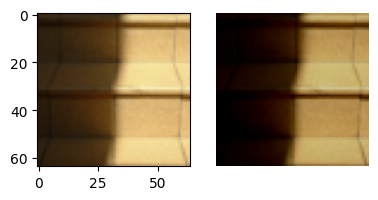

In [15]:
def apply_random_brightness(X_4d, value_range=50): # 50 is almost 20% of the 255 (maximum pixel value)
    # X_4d shape: (m, 64, 64, 3)
    m = X_4d.shape[0]
    
    # Generate random shifts for each image
    shifts = np.random.randint(-value_range, value_range, size=(m, 1, 1, 1))
    
    # Add shifts and clip to 0-255 range
    X_bright = np.clip(X_4d.astype(np.int16) + shifts, 0, 255)
    
    return X_bright.astype(np.uint8)

img_index = np.random.randint(0,train_set_x_orig.shape[0]) # randomly selecting an image and cropping it.
X_4d = train_set_x_orig[[img_index]]
img =X_4d[0]
bright_imgs = apply_random_brightness(X_4d, value_range =50)
bright_img= bright_imgs[0]

plt.figure(figsize=(4, 2))
plt.subplot(1,2,1)
plt.imshow(img)
plt.subplot(1,2,2)
plt.imshow(bright_img)

# plt.title(f"Pred: {y_hat[0,i]}, True: {test_set_y_orig[0, i]}")
plt.axis('off')
plt.tight_layout()
plt.show()


In [16]:
# rotaing the image

from scipy import ndimage


def augment_dataset(X_orig):
    
    # ROTATION to all the images.: --> List of 4 angles
    
    angle = np.random.randint(-20,+20)

        # Rotate the entire batch of images at once
        # reshape=False keeps the image at 64x64 so it doesn't grow
    X_rotated_batch = ndimage.rotate(X_orig, angle, axes=(1, 2), reshape=False)

    # CENTRE CROP TO THE ROTATED IMAGES

    zoom_factor = np.random.uniform(0.5, 1)
    X_rotated_cropped = apply_center_crop(X_rotated_batch, zoom_factor)

    # BRIGHTNESS RANDOMIZER 

    brightness_factor = 50 # almost 20% of 255 (maximum pixel value)
    X_rotated_cropped_bright = apply_random_brightness(X_rotated_cropped, value_range = brightness_factor)

    train_X_flatten = X_rotated_cropped_bright.reshape((train_set_x_orig.shape[0], -1)).T
    train_X_flatten = train_X_flatten.astype(float)
    train_X_flatten /= 255 

    # print('angle_rotated:', angle)
    # print('zoom factor', zoom_factor)
    # print('brightness:', brightness_factor)
    

    return train_X_flatten

# Run the augmentation
train_X_flatten = augment_dataset(train_set_x_orig)
print(f"New dataset size: {train_X_flatten.shape[1]} images") # Should be 

New dataset size: 281 images


In [17]:
# reshaping the test set 
train_set_y_orig = train_set_y_orig.T
test_set_y_orig = test_set_y_orig.T

# Flattening test X

# generalised version : # X_flatten = X_orig.reshape(X_orig.shape[0], -1).T  [ -1 computes 12288 for us]
test_X_flatten = test_set_x_orig.reshape((test_set_x_orig.shape[0], -1)).T
test_X_flatten = test_X_flatten.astype(float) # uint8 = unsigned = [0,255] will the range of pixel values.
test_X_flatten/= 255

print('Train set x shape',train_X_flatten.shape)
print('Train set y shape',train_set_y_orig.shape)
print('Test set x shape', test_X_flatten.shape)
print('Test set y shape', test_set_y_orig.shape)

Train set x shape (12288, 281)
Train set y shape (1, 281)
Test set x shape (12288, 50)
Test set y shape (1, 50)


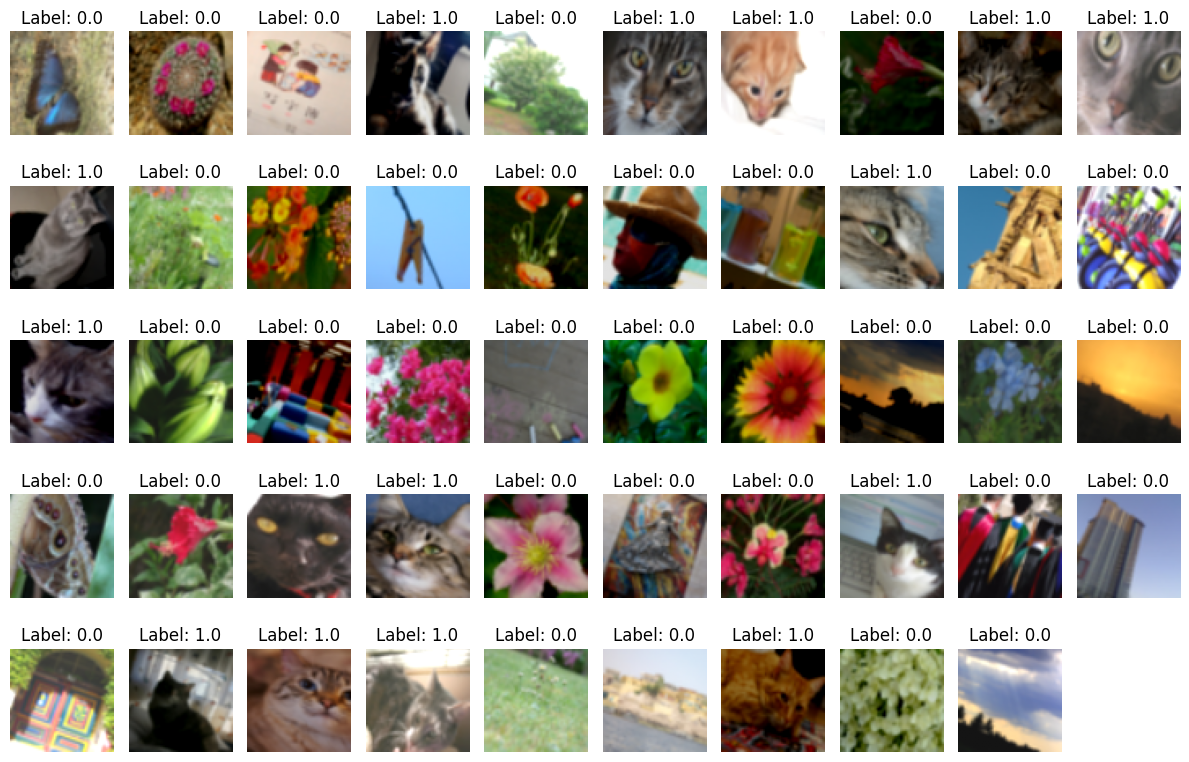

In [18]:
# seeing the images from 51 to 101 which has been randomly cropped, rotated, and brightness change

X = train_X_flatten.T.reshape(281, 64, 64, 3)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
for i in range(51,100,1): # show first 12 images
    plt.subplot(5,10, i-50 )
    plt.imshow(X[i])
    plt.title(f"Label: {train_set_y_orig[0,i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [19]:
# Initialising parameters

layers_dims = [12288,20,12,1]
L = len(layers_dims)


def initialise_parameters(layers_dims):
    parameters={}

    L = len(layers_dims)
    for l in range(1,L):
        parameters['W'+ str(l)] = np.random.randn(layers_dims[l], layers_dims[l-1]) * np.sqrt(2/layers_dims[l-1]) # he factor for relu 
        parameters['b'+ str(l)] = np.zeros((layers_dims[l],1))

    return parameters

# testing

parameters = initialise_parameters(layers_dims)



In [20]:
print(parameters.keys())
print(parameters['W1'].shape)

dict_keys(['W1', 'b1', 'W2', 'b2', 'W3', 'b3'])
(20, 12288)


https://gemini.google.com/share/59180b4b1003

Above link show how initializing the weights to zero in a deep neural network can lead to cloning while in logistics regression, it is fine. Thus we initialise the weights to zeros in this code


In [21]:
# defining activation functions

def activation(Z, l_num,L): # l_num = which layer number are we talking about.

    if l_num < L-1:
        return np.maximum(Z,0)
    elif l_num == L-1:
        Z =  np.clip(Z, -500, 500) # even after scaling down, Z was becoming big. Clip Prevents exp from blowing up. I Z becomes too big. e^bignumber cannot be stored.
        return 1/(1+ np.exp(-Z))

In [22]:
# definining feedforward function


def feedforward( parameters, X):
    
    L = len(parameters) // 2 + 1

    activations ={}
    preactivations={} # Z is called preactivation or wx+b

    activations['A0'] = X

    for l in range(1,L):
        preactivations['Z'+ str(l)] = np.dot(parameters['W'+ str(l)], activations['A'+ str(l-1)]) + parameters['b'+ str(l)]
        activations['A'+ str(l)] = activation(preactivations['Z'+ str(l)],l,L)

    return activations, preactivations

In [23]:
# defining cost function

def cost_with_regularization(activations,Y,m, parameters, lambd):
    
    # Calculate L based on how many weights are in the dictionary
    L = len(parameters) // 2 + 1
    
    A = activations['A'+ str(L-1)]
    A = np.clip(A, 1e-15, 1 - 1e-15)  #Keep A slightly away from 0 and 1. To not show log(0) error.
    cross_entropy_cost = (-1/m) * np.sum(Y * np.log(A) + (1- Y)* np.log(1-A))
    
    # L2 Regularization Cost (Sum of squares of all weights)
    l2_sum = 0
    for l in range(1,L):
        w = parameters['W'+ str(l)]
        l2_sum += np.sum(np.square(w))

    L2_cost = (lambd / (2 * m)) * l2_sum 
    
    """The 2 in the denominator is there to cancel out the power of 2 when you take the derivative during backpropagation,
    making the gradient update simpler: dW = (1/m)dZ.A_prev + (lambd/m)W
    """   
    return cross_entropy_cost + L2_cost

In [24]:
def dA_dZ(preactivations, activations , l):

    if l == L-1: # for the last layer where sigmoid is used.
        A_l = activations["A"+ str(l)]
        dA_dZ = A_l*(1-A_l)
        return dA_dZ
    else:
        Z = preactivations['Z'+ str(l)]
        dA_dZ = np.where(Z<=0,0,1) # for previous layers where relu activations are used
        return dA_dZ
        

In [25]:
def accuracy( activations,Y,m):
    A = activations['A'+ str(L-1)]
    result = np.where(A>= 0.50, 1,0)
    matches = np.where(result == Y) # np.where returns a tuple of arrays (one for each dimension)
    count = len(matches[0]) # Get the length of the first array in the tuple
    return count/ m

In [26]:
# For plotting the graphs 
train_costs, test_costs = [], []
train_accs, test_accs = [], []
iterations = []

In [27]:
# defining backpropagation

def backpropagation( activations, Y, preactivations, parameters, l_r, m, lambd ):

    L = len(parameters) // 2 + 1 #Get number of layers dynamically
    dZ = activations['A'+ str(L-1)] -Y  # for the sigmoid layer
    dA_s = {}

    parameters_gradient ={}

    for l in range(L-1, 0, -1):

        if l< L-1:
            dZ = dA_s['dA'+ str(l)] * dA_dZ(preactivations, activations, l)
            
        parameters_gradient['dW' + str(l)] = (1/m) * np.dot(dZ, activations["A"+ str(l-1)].T) + (lambd/m) * parameters['W' + str(l)]
        parameters_gradient['db' + str(l)] = (1/m) * np.sum(dZ, axis =1,keepdims = True)
        dA_s['dA'+ str(l-1)] = np.dot(parameters['W'+str(l)].T, dZ)

        parameters['W'+ str(l)] -= l_r * parameters_gradient['dW'+ str(l)]
        parameters['b'+ str(l)] -= l_r * parameters_gradient['db'+ str(l)]

    return parameters

In [28]:
# training the model and saving at appropriate time

import pickle
from datetime import datetime

l_r = 0.002
lambd = 25
num_iterations = 5000
train_m = train_set_y_orig.shape [1]
test_m = test_set_y_orig.shape [1]

for i in range(num_iterations +1):

    train_X_flatten = augment_dataset(train_set_x_orig)
    activations, preactivations = feedforward(parameters, train_X_flatten)

    if i%100 ==0:
        train_accuracy = accuracy(activations,train_set_y_orig, train_m )
        train_cost = cost_with_regularization( activations, train_set_y_orig, train_m, parameters, lambd)

        train_costs.append(train_cost)
        train_accs.append(train_accuracy)
        print(f"Iteration {i:5}: Train_Loss: {train_cost:.6f} | Train_Accuracy: {train_accuracy:.2%}")  

        
        test_A, test_Z = feedforward( parameters, test_X_flatten)
        test_accuracy = accuracy (test_A,test_set_y_orig, test_m )
        test_cost = cost_with_regularization(  test_A, test_set_y_orig, test_m, parameters, lambd )
        
        test_costs.append(test_cost)
        test_accs.append(test_accuracy)
        print(f"Iteration {i:5}: Test_Loss : {test_cost:.6f} | Test_Accuracy : {test_accuracy:.2%}")  

        iterations.append(i)

    parameters = backpropagation (activations,train_set_y_orig, preactivations, parameters,l_r,train_m, lambd )

            # --- PERIODIC SAVE LOGIC ---
    if i > 0 and i % 1000 == 0:
        # Create a timestamp like "20231027_143005"
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        
        # Create a unique filename
        filename = f"cat_model_iter{i}_{timestamp}.pkl"
        
        # Bundle the weights, biases, and metadata
        model_state = {
            "parameters": parameters,
            "iteration": i,
            "hyperparams": {"learning_rate": l_r, "lambd": lambd}
        }
        
        with open(filename, 'wb') as f:
            pickle.dump(model_state, f)
            
        print(f"\n[CHECKPOINT] Model saved as {filename}")

Iteration     0: Train_Loss: 3.905483 | Train_Accuracy: 48.04%
Iteration     0: Test_Loss : 18.080040 | Test_Accuracy : 34.00%
Iteration   100: Train_Loss: 3.538420 | Train_Accuracy: 65.84%
Iteration   100: Test_Loss : 16.956238 | Test_Accuracy : 68.00%
Iteration   200: Train_Loss: 3.397973 | Train_Accuracy: 69.40%
Iteration   200: Test_Loss : 16.345972 | Test_Accuracy : 70.00%
Iteration   300: Train_Loss: 3.271386 | Train_Accuracy: 70.46%
Iteration   300: Test_Loss : 15.787976 | Test_Accuracy : 74.00%
Iteration   400: Train_Loss: 3.135536 | Train_Accuracy: 79.36%
Iteration   400: Test_Loss : 15.241444 | Test_Accuracy : 78.00%
Iteration   500: Train_Loss: 3.071673 | Train_Accuracy: 74.73%
Iteration   500: Test_Loss : 14.730009 | Test_Accuracy : 80.00%
Iteration   600: Train_Loss: 2.929624 | Train_Accuracy: 82.56%
Iteration   600: Test_Loss : 14.261090 | Test_Accuracy : 78.00%
Iteration   700: Train_Loss: 2.847819 | Train_Accuracy: 81.49%
Iteration   700: Test_Loss : 13.783483 | Test_Ac

In [29]:
arr1 = np.array([1, 2, 3, 4, 5])
arr2 = np.array([1, 0, 3, 9, 5])

indices = np.where(arr1 == arr2)
indices

(array([0, 2, 4]),)

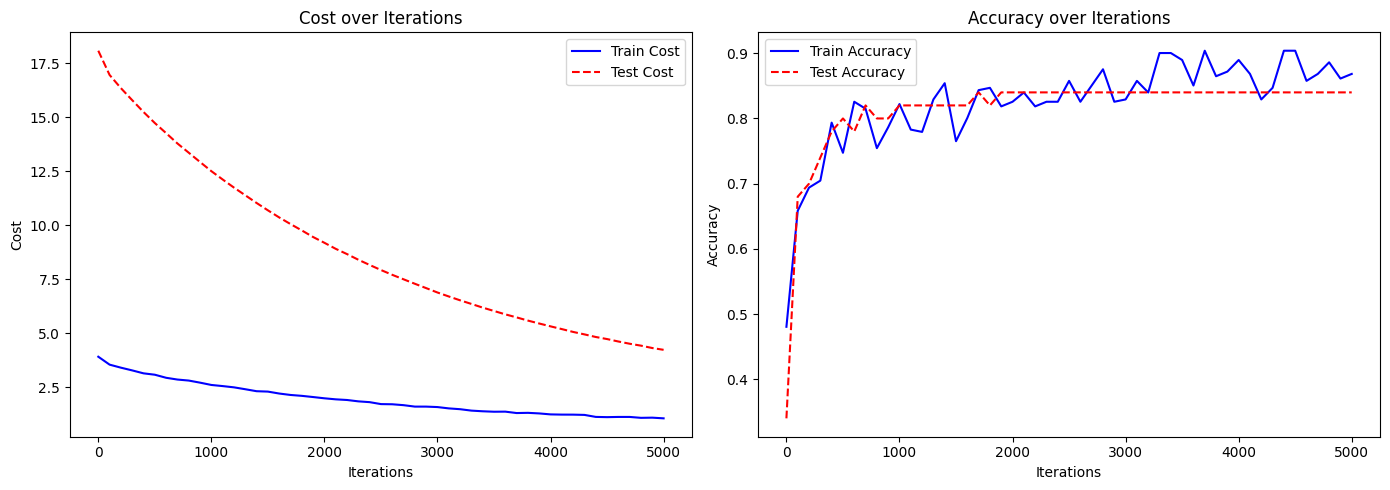

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# --- Plot 1: Loss (Cost) ---
plt.subplot(1, 2, 1)
plt.plot(iterations, train_costs, label='Train Cost', color='blue')
plt.plot(iterations, test_costs, label='Test Cost', color='red', linestyle='--')
plt.title('Cost over Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.legend()

# --- Plot 2: Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(iterations, train_accs, label='Train Accuracy', color='blue')
plt.plot(iterations, test_accs, label='Test Accuracy', color='red', linestyle='--')
plt.title('Accuracy over Iterations')
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

(array([13, 18, 19, 29, 34, 38, 44, 46]),)
[13 18 19 29 34 38 44 46]


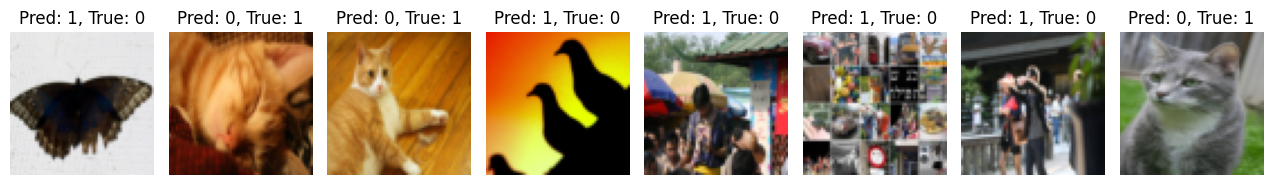

In [31]:
activations,preactivations = feedforward(parameters, test_X_flatten)


A3 = activations['A'+ str(L-1)]
y_hat = np.where(A3>=0.5, 1,0)

# mismatch is a tuple: (array_of_rows, array_of_columns)
mismatch_tuple = np.where(y_hat[0,:]!= test_set_y_orig[0,:] )
print(mismatch_tuple)

# Extract just the column indices (the actual image positions)
mismatch_indices = mismatch_tuple[0]

print(mismatch_indices)
num_mismatch = len(mismatch_indices)

import matplotlib.pyplot as plt
plt.figure(figsize=(16, 12))
for count,i in enumerate(mismatch_indices):
    # 1. Get the actual image index from your array

    plt.subplot(5,10, count+1)
    plt.imshow(test_set_x_orig[i])
    plt.title(f"Pred: {y_hat[0,i]}, True: {test_set_y_orig[0, i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [32]:
print(test_set_x_orig.shape)

(50, 64, 64, 3)
